# Paired HE6: figure_s15 inactive-virus classifier application

Apply the trained figure_s15 inactive-virus classifier (**story-20**, isotonic-calibrated **RF**,
**Caudoviricetes-only**) to six highly enriched bulk↔virome pairs under:

`results/uhvdb_toolkit/toolkit/referenceanalyze/sracha_fastp_deacon_sylph_csvtk_seqkit_coverm_genecoverage`

**Scope:** genomes with `ictv_class == "Caudoviricetes"` (matches training filter in
`meta["ictv_class_filter"]`).

**Ground truth**
- **TP** = bulk only (uninducible / inactive)
- **FP** = bulk + enriched (inducible / active)
- **FN** = enriched only

**Call rule:** `P(inactive) ≥ meta["thresh_90"]` (Liang OOF **95% precision** cutoff; ~0.873 for story-20 RF).
Joblib keys `thresh_90` / `thresh_75` / `thresh_50` map to 95% / 90% / 85% precision.

**Analyses**
1. Precision / recall (PR + ROC)
2. Proportion called uninducible — bulk vs enriched features
3. VHR precision / recall (cascade) — before vs after filter

Outputs → `paired_he6_results/`


In [36]:
### paths, imports, helpers
#!/usr/bin/env python3
"""Paired HE6 figure_s15 classifier application — runnable core used to build the notebook.

Uses the Caudoviricetes-only inactive-virus model (meta['ictv_class_filter']).
"""
from __future__ import annotations

import json
import math
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)

plt.rcParams.update({"font.size": 12})

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
FIG_S15 = Path(".").resolve()
if not (FIG_S15 / "phage_activity_model_full.joblib").exists():
    FIG_S15 = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_s15")
ROOT = FIG_S15.parents[1]
if FIG_S15.name != "figure_s15":
    ROOT = FIG_S15.parents[1]

RESULT_DIR = (
    FIG_S15
    / "results/uhvdb_toolkit/toolkit/referenceanalyze"
    / "sracha_fastp_deacon_sylph_csvtk_seqkit_coverm_genecoverage"
)
MODEL_DIR = FIG_S15
METADATA = ROOT / "uhvdb-manuscript/figure_s18/uhvdb_v5_final_metadata_v2.tsv.gz"
FIG1 = ROOT / "uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2"
PHIST = FIG1 / "uhvdb_phisthost.tsv.gz"
CRISPR = FIG1 / "uhvdb_crisprhost.tsv.gz"
GTDB = ROOT / "uhvdb-manuscript/figure_4/sylph_tax/gtdb_r214_metadata.tsv.gz"
OUT_DIR = FIG_S15 / "paired_he6_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENE_BREADTH_THRESHOLD = 0.8
COMPLETED_GROUPS = ["H24", "H60", "NCF007", "S08", "NC159", "NC178"]
VHR_THRESHOLDS = [0, 0.5, 1, 2, 4, 8, 16]
META_HALLMARK_COLLISION_COLS = (
    "n_hallmarks",
    "mcp_hallmark",
    "terl_hallmark",
    "portal_hallmark",
)

GENE_PROP_COLS = [
    "med_prop_capsid_packaging",
    "med_prop_dna_metabolism",
    "med_prop_tail",
    "med_prop_lysis",
    "med_prop_connector",
    "med_prop_transcription",
    "med_prop_integration",
    "med_prop_amg_host_takeover",
    "med_mcp_hallmark",
    "med_portal_hallmark",
    "med_terL_hallmark",
    "med_n_hallmarks",
]
PROF_FEAT_COLS = [
    "log_True_cov",
    "log_tax_abund",
    "log_seq_abund",
    "Adjusted_ANI",
    "Naive_ANI",
    "containment_frac",
    "Eff_lambda_ord",
    "ANI_interval_width",
    "Median_cov",
    "Mean_cov_geq1",
    "kmers_reassigned",
    "cov_evenness",
    "True_cov_rank",
    "tax_abund_rank",
    "ani",
]
GENE_STAT_COLS = [
    "gene_breadth_mean",
    "gene_breadth_std",
    "gene_breadth_cv",
    "frac_genes_breadth_ge_0_5",
    "frac_genes_breadth_ge_0_8",
    "gene_mean_depth_mean",
    "gene_mean_depth_std",
    "gene_occupancy",
    "n_struct_genes",
]


def with_bio_group_flags(df: pl.DataFrame) -> pl.DataFrame:
    cols = df.columns
    prep = []
    for name in ("pharokka_category", "phold_category", "empathi_annot", "pharokka_annot"):
        if name in cols:
            prep.append(pl.col(name).fill_null(""))
        else:
            prep.append(pl.lit("").alias(name))
    out = df.with_columns(prep).with_columns(
        [
            pl.col("empathi_annot")
            .str.split("|")
            .list.get(0, null_on_oob=True)
            .fill_null("")
            .alias("empathi_token0"),
            pl.col("empathi_annot")
            .str.split("|")
            .list.get(1, null_on_oob=True)
            .fill_null("")
            .alias("empathi_token1"),
        ]
    )
    return out.with_columns(
        [
            (
                (pl.col("pharokka_category") == "head and packaging")
                | pl.col("phold_category").str.contains("(?i)head|capsid|portal|terminase")
                | (pl.col("empathi_token0") == "pvp")
                | (pl.col("empathi_token0") == "packaging_assembly")
                | pl.col("empathi_token1").is_in(
                    ["capsid", "terminase", "portal", "head-tail_joining"]
                )
            ).alias("is_capsid_packaging"),
            (
                (pl.col("pharokka_category") == "DNA, RNA and nucleotide metabolism")
                | (pl.col("empathi_token0") == "DNA-associated")
                | (pl.col("empathi_token0") == "RNA-associated")
                | pl.col("empathi_token1").is_in(
                    ["nuclease", "annealing", "DNA_polymerase", "helicase"]
                )
            ).alias("is_dna_metabolism"),
            (
                (pl.col("pharokka_category") == "tail")
                | pl.col("phold_category").str.contains(r"(?i)\btail\b")
                | (pl.col("empathi_token1") == "tail")
            ).alias("is_tail"),
            (
                (pl.col("pharokka_category") == "lysis")
                | pl.col("phold_category").str.contains("(?i)lysis|holin|endolysin")
                | (pl.col("empathi_token0") == "lysis")
                | (pl.col("empathi_token0") == "cell_wall_depolymerase")
                | pl.col("empathi_token1").is_in(["lysis", "holin"])
            ).alias("is_lysis"),
            (
                (pl.col("pharokka_category") == "connector")
                | pl.col("phold_category").str.contains("(?i)connector|head-tail|head–tail")
            ).alias("is_connector"),
            (
                (pl.col("pharokka_category") == "transcription regulation")
                | (pl.col("empathi_token0") == "transcriptional_regulator")
                | (pl.col("empathi_token1") == "transcriptional_regulator")
            ).alias("is_transcription"),
            (
                (pl.col("pharokka_category") == "integration and excision")
                | pl.col("phold_category").str.contains("(?i)integrase|integration")
                | (pl.col("empathi_token1") == "integration")
            ).alias("is_integration"),
            (
                (
                    pl.col("pharokka_category")
                    == "moron, auxiliary metabolic gene and host takeover"
                )
                | pl.col("phold_category").str.contains(
                    r"(?i)auxiliary metabolic|host takeover|moron|anti[- ]?defen[cs]e"
                )
                | pl.col("empathi_token0").is_in(
                    ["amg", "auxiliary_metabolic", "host_takeover", "moron", "anti-defense"]
                )
                | pl.col("empathi_token1").is_in(
                    ["amg", "auxiliary_metabolic", "host_takeover", "moron", "anti-defense"]
                )
            ).alias("is_amg_host_takeover"),
        ]
    )


def load_depth(path: Path, sample_id: str) -> pl.DataFrame:
    raw = pl.read_csv(path, separator="\t")
    cols = raw.columns
    rename = {
        cols[0]: "contig_id",
        cols[1]: "trimmed_mean",
        cols[2]: "mean",
        cols[3]: "variance",
        cols[4]: "covered_bases",
        cols[5]: "length",
    }
    group = sample_id.rsplit("_", 1)[0]
    return (
        raw.rename(rename)
        .with_columns(
            [
                pl.lit(sample_id).alias("sample_id"),
                pl.lit(group).alias("group"),
                (pl.col("covered_bases") / pl.col("length")).alias("breadth"),
                (1 - math.e ** (-0.833 * pl.col("mean"))).alias("expected_breadth"),
            ]
        )
        .with_columns(
            pl.when(pl.col("expected_breadth") > 1e-6)
            .then(pl.col("breadth") / pl.col("expected_breadth"))
            .otherwise(None)
            .alias("breadth_ratio")
        )
    )


def gene_prop_agg(df: pl.DataFrame) -> pl.DataFrame:
    return (
        with_bio_group_flags(df)
        .group_by(["sample_id", "genomovar_rep"])
        .agg(
            [
                pl.len().alias("n_genes_covered"),
                pl.col("is_capsid_packaging").mean().alias("prop_capsid_packaging"),
                pl.col("is_dna_metabolism").mean().alias("prop_dna_metabolism"),
                pl.col("is_tail").mean().alias("prop_tail"),
                pl.col("is_lysis").mean().alias("prop_lysis"),
                pl.col("is_connector").mean().alias("prop_connector"),
                pl.col("is_transcription").mean().alias("prop_transcription"),
                pl.col("is_integration").mean().alias("prop_integration"),
                pl.col("is_amg_host_takeover").mean().alias("prop_amg_host_takeover"),
                (
                    ((pl.col("pharokka_annot") == "major head protein").sum() >= 1)
                    | ((pl.col("phold_category") == "major head protein").sum() >= 1)
                    | ((pl.col("empathi_annot") == "pvp|capsid|major_capsid").sum() >= 1)
                )
                .cast(pl.UInt32)
                .alias("mcp_hallmark"),
                (
                    ((pl.col("pharokka_annot") == "terminase large subunit").sum() >= 1)
                    | ((pl.col("phold_category") == "terminase large subunit").sum() >= 1)
                    | (
                        (
                            pl.col("empathi_annot")
                            == "DNA-associated|terminase|packaging_assembly"
                        ).sum()
                        >= 1
                    )
                )
                .cast(pl.UInt32)
                .alias("terl_hallmark"),
                (
                    ((pl.col("pharokka_annot") == "portal protein").sum() >= 1)
                    | ((pl.col("phold_category") == "portal protein").sum() >= 1)
                    | ((pl.col("empathi_annot") == "pvp|portal").sum() >= 1)
                )
                .cast(pl.UInt32)
                .alias("portal_hallmark"),
            ]
        )
        .with_columns(
            (pl.col("mcp_hallmark") + pl.col("terl_hallmark") + pl.col("portal_hallmark")).alias(
                "n_hallmarks"
            )
        )
    )


def _parse_containment_frac(s):
    if s is None or not isinstance(s, str) or "/" not in s:
        return None
    try:
        a, b = s.split("/", 1)
        a, b = float(a), float(b)
        return float(a / b) if b else None
    except Exception:
        return None


def _parse_ani_width(s):
    if s is None or not isinstance(s, str) or str(s).startswith("NA") or "-" not in str(s):
        return None
    try:
        lo, hi = str(s).split("-", 1)
        return float(hi) - float(lo)
    except Exception:
        return None


def with_viral_gene_frac(df: pl.DataFrame) -> pl.DataFrame:
    """Story-20 derived feature: CheckV viral_genes / (viral_genes + host_genes)."""
    return df.with_columns(
        (
            pl.col("viral_genes").cast(pl.Float64, strict=False)
            / (
                pl.col("viral_genes").cast(pl.Float64, strict=False)
                + pl.col("host_genes").cast(pl.Float64, strict=False)
            )
        ).alias("viral_gene_frac")
    )


def pr_curve_for_plot(y_true, proba, min_predicted: int = 20):
    """PR coordinates for figures.

    sklearn appends (recall=0, precision=1) with no threshold, and the first
    few high-score isotonic ties have too few calls for a stable precision.
    Drop those, then extend left to recall=0 at the first stable precision so
    the curve does not start with a tiny-N cliff. Report AUPRC from
    average_precision_score on the full scores, not this trim.
    """
    y = np.asarray(y_true).astype(int)
    p = np.asarray(proba, dtype=float)
    prec, rec, _thr = precision_recall_curve(y, p)
    prec, rec = np.asarray(prec[:-1], dtype=float), np.asarray(rec[:-1], dtype=float)
    n_pos = max(int(y.sum()), 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        n_pred = rec * n_pos / prec
    keep = np.isfinite(n_pred) & (n_pred >= min_predicted)
    if keep.any():
        rec, prec = rec[keep], prec[keep]
    # sklearn returns decreasing recall; extend to R=0 at the first *stable*
    # high-score precision (last remaining point), not the prevalence end.
    rec = np.r_[rec, 0.0]
    prec = np.r_[prec, prec[-1]]
    return rec, prec


def majority_host(df: pl.DataFrame, col: str) -> pl.DataFrame:
    return (
        df.filter(pl.col(col).is_not_null())
        .group_by(["species_cluster_id", col])
        .agg(pl.len().alias("n"))
        .sort(["species_cluster_id", "n", col], descending=[False, True, False])
        .unique("species_cluster_id", maintain_order=True)
        .select(["species_cluster_id", col])
    )


def enriched_prop_curve(frame: pd.DataFrame, thresholds) -> pd.DataFrame:
    """Precision/recall of VHR ≥ t as a call for enriched/induced (pr_cat==FP).

    Precision = n_fp / n among detections with phage_host_ratio ≥ t
    Recall    = n_fp / n_fp_total in ``frame``
    """
    n_fp_total = int((frame["pr_cat"] == "FP").sum())
    rows = []
    for t in thresholds:
        in_thr = frame.loc[frame["phage_host_ratio"] >= t]
        n = len(in_thr)
        n_enriched = int((in_thr["pr_cat"] == "FP").sum())
        precision = (n_enriched / n) if n else None
        recall = (n_enriched / n_fp_total) if n_fp_total else None
        rows.append(
            {
                "vhr_threshold": t,
                "n_bulk": n,
                "n_also_enriched": n_enriched,
                "n_fp_total": n_fp_total,
                "precision": precision,
                "recall": recall,
                # alias kept for downstream TSV compatibility
                "prop_also_enriched": precision,
            }
        )
    return pd.DataFrame(rows)


In [37]:
### load model, discover pairs, load CoverM / gene / sylph + build features
meta = joblib.load(MODEL_DIR / "phage_model_metadata_full.joblib")
pipeline = joblib.load(MODEL_DIR / "phage_activity_model_full.joblib")
numeric_cols = list(meta["numeric_cols"])
thr = float(meta["thresh_90"])
ICTV_CLASS_FILTER = meta.get("ictv_class_filter", "Caudoviricetes")
if ICTV_CLASS_FILTER != "Caudoviricetes":
    raise ValueError(
        f"Expected Caudoviricetes model; got ictv_class_filter={ICTV_CLASS_FILTER!r}"
    )
print(
    f"features={len(numeric_cols)}  feature_set={meta.get('feature_set')}  "
    f"learner={meta.get('learner')}  thresh_90={thr:.4f}  "
    f"ictv_class_filter={ICTV_CLASS_FILTER}"
)

available = {p.name.replace(".depth.tsv.gz", "") for p in RESULT_DIR.glob("*.depth.tsv.gz")}
pairs = [
    g
    for g in COMPLETED_GROUPS
    if f"{g}_bulk" in available and f"{g}_enriched" in available
]
if not pairs:
    raise SystemExit(f"No completed pairs in {RESULT_DIR}")
print("pairs:", pairs)

uhvdb_cols = pl.read_csv(METADATA, separator="\t", n_rows=0).columns
uhvdb_full = pl.read_csv(METADATA, separator="\t")
uhvdb = uhvdb_full.drop([c for c in META_HALLMARK_COLLISION_COLS if c in uhvdb_cols])
id_map = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id"])
    .unique("uhvdb_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

depth_lst, gene_raw_lst, prof_lst = [], [], []
for g in pairs:
    for kind in ("bulk", "enriched"):
        sid = f"{g}_{kind}"
        depth_lst.append(load_depth(RESULT_DIR / f"{sid}.depth.tsv.gz", sid))
        gene_raw_lst.append(
            pl.read_csv(RESULT_DIR / f"{sid}.gene_coverage.tsv.gz", separator="\t")
            .filter(pl.col("genomovar_rep").str.starts_with("UHVDB-"))
            .with_columns(pl.lit(sid).alias("sample_id"))
        )
        prof_lst.append(
            pl.read_csv(RESULT_DIR / f"{sid}.profile.tsv", separator="\t")
            .filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Contig_name").alias("uhvdb_id"),
                    pl.col("True_cov").cast(pl.Float64),
                    pl.col("Taxonomic_abundance").cast(pl.Float64).alias("tax_abund"),
                    pl.col("Sequence_abundance").cast(pl.Float64).alias("seq_abund"),
                    pl.col("Adjusted_ANI").cast(pl.Float64),
                    pl.col("Naive_ANI").cast(pl.Float64),
                    pl.col("Median_cov").cast(pl.Float64),
                    pl.col("Mean_cov_geq1").cast(pl.Float64),
                    pl.col("kmers_reassigned").cast(pl.Float64),
                    pl.col("Containment_ind").cast(pl.Utf8),
                    pl.col("Eff_lambda").cast(pl.Utf8),
                    pl.col("ANI_5-95_percentile").cast(pl.Utf8).alias("ANI_5_95"),
                ]
            )
        )
coverm_df = pl.concat(depth_lst)
gene_raw = pl.concat(gene_raw_lst)
prof_raw = pl.concat(prof_lst)

# Labels
joined = coverm_df.filter(pl.col("sample_id").str.contains("_bulk")).join(
    coverm_df.filter(pl.col("sample_id").str.contains("_enriched")),
    on=["group", "contig_id"],
    suffix="_enriched",
    how="full",
)
coalesce_exprs = []
if "contig_id_enriched" in joined.columns:
    coalesce_exprs.append(
        pl.coalesce([pl.col("contig_id"), pl.col("contig_id_enriched")]).alias("contig_id")
    )
if "group_enriched" in joined.columns:
    coalesce_exprs.append(
        pl.coalesce([pl.col("group"), pl.col("group_enriched")]).alias("group")
    )
if coalesce_exprs:
    joined = joined.with_columns(coalesce_exprs)

labeled = (
    joined.filter(pl.col("contig_id").is_not_null())
    .join(uhvdb, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .with_columns(
        [
            pl.coalesce([pl.col("sample_id"), pl.col("sample_id_enriched")]).alias(
                "sample_id"
            ),
            pl.col("species_cluster_id").cast(pl.Int64),
        ]
    )
    .with_columns(
        [
            pl.col(c).fill_null(0.0)
            for c in [
                "breadth",
                "breadth_enriched",
                "breadth_ratio",
                "breadth_ratio_enriched",
                "variance",
                "trimmed_mean",
                "variance_enriched",
                "trimmed_mean_enriched",
            ]
            if c in joined.columns or True
        ]
    )
    .with_columns(
        pl.when((pl.col("breadth_ratio") > 0) & (pl.col("breadth_ratio_enriched") == 0))
        .then(pl.lit("TP"))
        .when((pl.col("breadth_ratio") == 0) & (pl.col("breadth_ratio_enriched") > 0))
        .then(pl.lit("FN"))
        .when((pl.col("breadth_ratio") > 0) & (pl.col("breadth_ratio_enriched") > 0))
        .then(pl.lit("FP"))
        .otherwise(pl.lit("TN"))
        .alias("pr_cat")
    )
        .unique(["species_cluster_id", "group"], keep="first")
)
_n_labeled_before = labeled.height
_ictv_counts = (
    labeled.group_by("ictv_class").agg(pl.len().alias("n")).sort("n", descending=True)
)
print("ICTV class counts before filter:")
print(_ictv_counts)
labeled = labeled.filter(pl.col("ictv_class") == ICTV_CLASS_FILTER)
print(
    f"Restricted to {ICTV_CLASS_FILTER}: {_n_labeled_before:,} -> {labeled.height:,} rows "
    f"({labeled.height / max(_n_labeled_before, 1):.1%})"
)
print("pr_cat:", labeled["pr_cat"].value_counts().sort("pr_cat"))

# Species quality counts
_quality = (
    uhvdb_full.with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .group_by("species_cluster_id")
    .agg(
        [
            (pl.col("checkv_quality") == "Complete").sum().alias("complete_count"),
            (pl.col("checkv_quality") == "High-quality").sum().alias("high_quality_count"),
        ]
    )
)

_sp_meta_agg = uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep")).with_columns(
    pl.col("species_cluster_id").cast(pl.Int64)
)
_meta_sp = (
    _sp_meta_agg.unique("species_cluster_id", keep="first")
    .with_columns(
        [
            pl.col("virulent").alias("annot_virulent"),
            pl.col("virulent").alias("med_virulent_score"),
            pl.col("temperate"),
            pl.col("phrog_integrases").cast(pl.Float64),
            pl.col("phrog_integration_excision").cast(pl.Float64),
            pl.col("empathi_integration").cast(pl.Float64),
            (pl.col("integration_status") == "integrated")
            .cast(pl.Float64)
            .alias("is_integrated"),
            (
                pl.col("provirus")
                .cast(pl.Utf8)
                .str.to_lowercase()
                .is_in(["yes", "true", "1"])
            )
            .cast(pl.Float64)
            .alias("is_provirus"),
            pl.col("num_lysis").cast(pl.Float64),
            pl.col("num_tail").cast(pl.Float64),
            pl.col("num_capsid").cast(pl.Float64),
            pl.col("num_proteins").cast(pl.Float64),
            pl.col("mcp_hallmark").cast(pl.Float64).alias("annot_mcp_hallmark"),
            pl.col("terl_hallmark").cast(pl.Float64).alias("annot_terl_hallmark"),
            pl.col("portal_hallmark").cast(pl.Float64).alias("annot_portal_hallmark"),
            pl.col("n_hallmarks").cast(pl.Float64).alias("annot_n_hallmarks"),
            pl.col("virus_hallmarks").cast(pl.Float64),
            pl.col("aai_id").alias("annot_aai_id"),
            pl.col("aai_af").alias("annot_aai_af"),
            ((pl.col("aai_id") / 100) * pl.col("aai_af")).alias("med_aai_id_af"),
            pl.col("aai_completeness"),
            pl.when(pl.col("aai_confidence") == "low")
            .then(0.0)
            .when(pl.col("aai_confidence") == "medium")
            .then(1.0)
            .when(pl.col("aai_confidence") == "high")
            .then(2.0)
            .otherwise(1.0)
            .alias("aai_confidence_ord"),
            pl.col("Score"),
            pl.col("kmer_freq"),
            pl.col("completeness"),
            pl.col("virus_score"),
            pl.col("host_genes"),
            pl.col("viral_genes"),
            pl.col("contig_length"),
            pl.col("n_genes"),
            pl.col("topology")
            .is_in(["DTR", "ITR"])
            .cast(pl.Float64)
            .alias("has_terminal_repeats"),
            (pl.col("topology") == "DTR").cast(pl.Float64).alias("is_DTR"),
            (pl.col("topology") == "ITR").cast(pl.Float64).alias("is_ITR"),
            (pl.col("topology") == "Provirus")
            .cast(pl.Float64)
            .alias("is_topology_provirus"),
            (
                pl.col("proviral_length")
                .cast(pl.Utf8)
                .replace("NA", None)
                .cast(pl.Float64, strict=False)
                / pl.col("contig_length")
            ).alias("proviral_frac"),
            pl.col("completeness_method")
            .cast(pl.Utf8)
            .str.contains("DTR")
            .cast(pl.Float64)
            .alias("cm_dtr"),
        ]
    )
    .with_columns(
        [
            (pl.col("num_lysis") / (pl.col("contig_length") / 1000)).alias(
                "num_lysis_per_kb"
            ),
            (pl.col("num_tail") / (pl.col("contig_length") / 1000)).alias("num_tail_per_kb"),
            (pl.col("num_capsid") / (pl.col("contig_length") / 1000)).alias(
                "num_capsid_per_kb"
            ),
            (pl.col("num_proteins") / (pl.col("contig_length") / 1000)).alias(
                "num_proteins_per_kb"
            ),
            (pl.col("phrog_integrases") / (pl.col("contig_length") / 1000)).alias(
                "phrog_integrases_per_kb"
            ),
            (pl.col("phrog_integration_excision") / (pl.col("contig_length") / 1000)).alias(
                "phrog_integration_excision_per_kb"
            ),
            (pl.col("empathi_integration") / (pl.col("contig_length") / 1000)).alias(
                "empathi_integration_per_kb"
            ),
            (pl.col("annot_n_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "annot_n_hallmarks_per_kb"
            ),
            (pl.col("virus_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "virus_hallmarks_per_kb"
            ),
            pl.col("contig_length").log1p().alias("log_contig_length"),
            pl.col("n_genes").log1p().alias("log_n_genes"),
        ]
    )
)

def make_gene_prop(kind: str) -> pl.DataFrame:
    pat = f"_{kind}"
    grp_pat = f"_{kind}$"
    return (
        gene_prop_agg(
            gene_raw.filter(pl.col("sample_id").str.contains(pat)).filter(
                pl.col("breadth") > GENE_BREADTH_THRESHOLD
            )
        )
        .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
        .with_columns(
            [
                pl.col("prop_capsid_packaging").alias("med_prop_capsid_packaging"),
                pl.col("prop_dna_metabolism").alias("med_prop_dna_metabolism"),
                pl.col("prop_tail").alias("med_prop_tail"),
                pl.col("prop_lysis").alias("med_prop_lysis"),
                pl.col("prop_connector").alias("med_prop_connector"),
                pl.col("prop_transcription").alias("med_prop_transcription"),
                pl.col("prop_integration").alias("med_prop_integration"),
                pl.col("prop_amg_host_takeover").alias("med_prop_amg_host_takeover"),
                pl.col("mcp_hallmark").alias("med_mcp_hallmark"),
                pl.col("portal_hallmark").alias("med_portal_hallmark"),
                pl.col("terl_hallmark").alias("med_terL_hallmark"),
                pl.col("n_hallmarks").alias("med_n_hallmarks"),
                pl.col("sample_id").str.replace(grp_pat, "").alias("group"),
            ]
        )
        .unique(["group", "species_cluster_id"], keep="first")
    )

gene_prop_bulk = make_gene_prop("bulk")
gene_prop_enr = make_gene_prop("enriched")

_prof_sp = (
    prof_raw.join(id_map, on="uhvdb_id", how="inner")
    .sort(["sample_id", "species_cluster_id", "tax_abund"], descending=[False, False, True])
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(
        [
            pl.col("Containment_ind")
            .map_elements(_parse_containment_frac, return_dtype=pl.Float64)
            .alias("containment_frac"),
            (
                pl.when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "LOW")
                .then(0.0)
                .when(
                    pl.col("Eff_lambda")
                    .cast(pl.Utf8)
                    .str.to_uppercase()
                    .is_in(["MEDIUM", "MED"])
                )
                .then(1.0)
                .when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "HIGH")
                .then(2.0)
                .otherwise(None)
                .alias("Eff_lambda_ord")
            ),
            pl.col("ANI_5_95")
            .map_elements(_parse_ani_width, return_dtype=pl.Float64)
            .alias("ANI_interval_width"),
            (pl.col("Median_cov") / pl.col("Mean_cov_geq1")).alias("cov_evenness"),
            pl.col("True_cov").log1p().alias("log_True_cov"),
            pl.col("tax_abund").fill_null(0).log1p().alias("log_tax_abund"),
            pl.col("seq_abund").fill_null(0).log1p().alias("log_seq_abund"),
            pl.col("Adjusted_ANI").alias("ani"),
        ]
    )
)
_prof_sp = (
    _prof_sp.with_columns(
        [
            pl.col("True_cov").rank(method="average").over("sample_id").alias("_tc_rank"),
            pl.col("tax_abund").rank(method="average").over("sample_id").alias("_ta_rank"),
            pl.len().over("sample_id").alias("_n_in_sample"),
        ]
    ).with_columns(
        [
            (pl.col("_tc_rank") / pl.col("_n_in_sample")).alias("True_cov_rank"),
            (pl.col("_ta_rank") / pl.col("_n_in_sample")).alias("tax_abund_rank"),
        ]
    )
)

_struct = (
    (pl.col("pharokka_annot") == "major head protein")
    | (pl.col("phold_category") == "major head protein")
    | (pl.col("empathi_annot") == "pvp|capsid|major_capsid")
    | (pl.col("pharokka_annot") == "terminase large subunit")
    | (pl.col("phold_category") == "terminase large subunit")
    | (pl.col("empathi_annot") == "DNA-associated|terminase|packaging_assembly")
    | (pl.col("pharokka_annot") == "portal protein")
    | (pl.col("phold_category") == "portal protein")
    | (pl.col("empathi_annot") == "pvp|portal")
)
_gene_stats = (
    gene_raw.with_columns(_struct.alias("is_struct"))
    .group_by(["sample_id", "genomovar_rep"])
    .agg(
        [
            pl.col("breadth").mean().alias("gene_breadth_mean"),
            pl.col("breadth").std().alias("gene_breadth_std"),
            (pl.col("breadth") >= 0.5).mean().alias("frac_genes_breadth_ge_0_5"),
            (pl.col("breadth") >= 0.8).mean().alias("frac_genes_breadth_ge_0_8"),
            pl.col("mean_depth").mean().alias("gene_mean_depth_mean"),
            pl.col("mean_depth").std().alias("gene_mean_depth_std"),
            pl.col("is_struct").sum().cast(pl.Float64).alias("n_struct_genes"),
            (pl.col("breadth") > GENE_BREADTH_THRESHOLD)
            .sum()
            .cast(pl.Float64)
            .alias("n_genes_covered"),
        ]
    )
    .with_columns(
        (pl.col("gene_breadth_std") / pl.col("gene_breadth_mean")).alias("gene_breadth_cv")
    )
    .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
    .sort(
        ["sample_id", "species_cluster_id", "n_genes_covered"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .join(
        _meta_sp.select(["species_cluster_id", "n_genes"]),
        on="species_cluster_id",
        how="left",
    )
    .with_columns((pl.col("n_genes_covered") / pl.col("n_genes")).alias("gene_occupancy"))
)

def assemble(kind: str) -> pl.DataFrame:
    if kind == "bulk":
        base = labeled.filter(pl.col("pr_cat").is_in(["TP", "FP"])).with_columns(
            [
                pl.when(pl.col("trimmed_mean") > 0)
                .then(pl.col("variance") / pl.col("trimmed_mean"))
                .otherwise(None)
                .alias("variance_ratio"),
                (pl.col("group") + "_bulk").alias("sample_id_feat"),
            ]
        )
        gene_prop = gene_prop_bulk
    else:
        base = labeled.filter(pl.col("pr_cat").is_in(["FP", "FN"])).with_columns(
            [
                pl.col("breadth_enriched").alias("breadth"),
                pl.col("breadth_ratio_enriched").alias("breadth_ratio"),
                pl.when(pl.col("trimmed_mean_enriched") > 0)
                .then(pl.col("variance_enriched") / pl.col("trimmed_mean_enriched"))
                .otherwise(None)
                .alias("variance_ratio"),
                (pl.col("group") + "_enriched").alias("sample_id_feat"),
            ]
        )
        gene_prop = gene_prop_enr
    return with_viral_gene_frac(
        base.join(_quality, on="species_cluster_id", how="left")
        .join(_meta_sp, on="species_cluster_id", how="left")
        .join(
            gene_prop.select(["group", "species_cluster_id"] + GENE_PROP_COLS),
            on=["group", "species_cluster_id"],
            how="left",
        )
        .join(
            _prof_sp.select(["sample_id", "species_cluster_id"] + PROF_FEAT_COLS).rename(
                {"sample_id": "sample_id_feat"}
            ),
            on=["sample_id_feat", "species_cluster_id"],
            how="left",
        )
        .join(
            _gene_stats.select(["sample_id", "species_cluster_id"] + GENE_STAT_COLS).rename(
                {"sample_id": "sample_id_feat"}
            ),
            on=["sample_id_feat", "species_cluster_id"],
            how="left",
        )
    )


features=20  feature_set=story20  learner=rf_isotonic  thresh_90=0.8732  ictv_class_filter=Caudoviricetes
pairs: ['H24', 'H60', 'NCF007', 'S08', 'NC159', 'NC178']
ICTV class counts before filter:
shape: (6, 2)
┌────────────────────┬──────┐
│ ictv_class         ┆ n    │
│ ---                ┆ ---  │
│ str                ┆ u32  │
╞════════════════════╪══════╡
│ Caudoviricetes     ┆ 3202 │
│ Faserviricetes     ┆ 106  │
│ Malgrandaviricetes ┆ 84   │
│ Arfiviricetes      ┆ 30   │
│ Howeltoviricetes   ┆ 2    │
│ Revtraviricetes    ┆ 1    │
└────────────────────┴──────┘
Restricted to Caudoviricetes: 3,425 -> 3,202 rows (93.5%)
pr_cat: shape: (3, 2)
┌────────┬───────┐
│ pr_cat ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ FN     ┆ 722   │
│ FP     ┆ 260   │
│ TP     ┆ 2220  │
└────────┴───────┘


In [38]:
### score classifier (Caudoviricetes; p ≥ meta thresh_90) + metrics
bulk_feat = with_viral_gene_frac(assemble("bulk"))
enr_feat = with_viral_gene_frac(assemble("enriched"))
missing = [c for c in numeric_cols if c not in bulk_feat.columns]
if missing:
    raise KeyError(f"Missing features: {missing}")
null_frac = np.mean(
    [bulk_feat[c].null_count() / max(bulk_feat.height, 1) for c in numeric_cols]
)
print(f"bulk n={bulk_feat.height} enr n={enr_feat.height} mean_null_frac={null_frac:.3f}")

# Score
bulk = bulk_feat.to_pandas()
y_true = (bulk["pr_cat"] == "TP").astype(int)
X = bulk.reindex(columns=numeric_cols)
proba = pipeline.predict_proba(X)[:, 1]
bulk["predicted_inactive_probability"] = proba
bulk["y_true_uninducible"] = y_true
bulk["predicted_uninducible"] = (proba >= thr).astype(int)

enr = enr_feat.to_pandas()
Xe = enr.reindex(columns=numeric_cols)
enr["predicted_inactive_probability"] = pipeline.predict_proba(Xe)[:, 1]
enr["predicted_uninducible"] = (enr["predicted_inactive_probability"] >= thr).astype(int)

auroc = roc_auc_score(y_true, proba)
auprc = average_precision_score(y_true, proba)
print(f"AUROC={auroc:.3f} AUPRC={auprc:.3f}")

thresholds = {
    "thresh_90": thr,
    "thresh_75": float(meta["thresh_75"]),
    "thresh_50": float(meta["thresh_50"]),
}
metric_rows = []
for name, t in thresholds.items():
    pred = (proba >= t).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    metric_rows.append(
        {
            "threshold_name": name,
            "threshold": t,
            "n_bulk": len(bulk),
            "n_predicted": int(pred.sum()),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "mcc": matthews_corrcoef(y_true, pred) if len(np.unique(pred)) > 1 else np.nan,
            "auroc": auroc,
            "auprc": auprc,
        }
    )
    print(
        f"[{name}] p≥{t:.3f}: prec={prec:.3f} rec={rec:.3f} "
        f"pred={int(pred.sum())}/{len(bulk)}"
    )
metrics = pd.DataFrame(metric_rows)

pg_rows = []
for g, sub in bulk.groupby("group", observed=True):
    prec, rec, f1, _ = precision_recall_fscore_support(
        sub["y_true_uninducible"],
        sub["predicted_uninducible"],
        average="binary",
        zero_division=0,
    )
    pg_rows.append(
        {
            "group": g,
            "n_bulk": len(sub),
            "n_tp": int((sub["pr_cat"] == "TP").sum()),
            "n_fp": int((sub["pr_cat"] == "FP").sum()),
            "n_pred": int(sub["predicted_uninducible"].sum()),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "mean_prob": float(sub["predicted_inactive_probability"].mean()),
        }
    )
by_group = pd.DataFrame(pg_rows)
print(by_group.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# Prop called
prop_rows = []
for src, df in [("bulk_features", bulk), ("enriched_features", enr)]:
    for cat, sub in df.groupby("pr_cat"):
        prop_rows.append(
            {
                "feature_context": src,
                "pr_cat": cat,
                "n": len(sub),
                "n_predicted_uninducible": int(sub["predicted_uninducible"].sum()),
                "prop_predicted_uninducible": float(sub["predicted_uninducible"].mean()),
                "mean_prob": float(sub["predicted_inactive_probability"].mean()),
            }
        )
prop_called = pd.DataFrame(prop_rows)
print(prop_called.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


bulk n=2480 enr n=982 mean_null_frac=0.003
AUROC=0.677 AUPRC=0.930
[thresh_90] p≥0.873: prec=0.945 rec=0.475 pred=1116/2480
[thresh_75] p≥0.772: prec=0.941 rec=0.681 pred=1606/2480
[thresh_50] p≥0.646: prec=0.928 rec=0.809 pred=1935/2480
 group  n_bulk  n_tp  n_fp  n_pred  precision  recall    f1  mean_prob
   H24     430   330   100     196      0.898   0.533 0.669      0.782
   H60     185   131    54      99      0.848   0.641 0.730      0.812
 NC159     327   311    16     127      0.921   0.376 0.534      0.764
 NC178     553   506    47     256      0.984   0.498 0.661      0.784
NCF007     532   518    14     216      0.986   0.411 0.580      0.762
   S08     453   424    29     222      0.959   0.502 0.659      0.782
  feature_context pr_cat    n  n_predicted_uninducible  prop_predicted_uninducible  mean_prob
    bulk_features     FP  260                       61                       0.235      0.641
    bulk_features     TP 2220                     1055                       

In [39]:
### PR / ROC / prop-called plots
# --- Plots: PR / ROC / score dist / prop called ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
rec_c, prec_c = pr_curve_for_plot(y_true, proba)
fpr, tpr, _ = roc_curve(y_true, proba)
pred_at_thr = (proba >= thr).astype(int)
thr_prec, thr_rec, _, _ = precision_recall_fscore_support(
    y_true, pred_at_thr, average="binary", zero_division=0
)
tn, fp_c, fn_c, tp_c = confusion_matrix(y_true, pred_at_thr, labels=[0, 1]).ravel()
thr_fpr = fp_c / (fp_c + tn) if (fp_c + tn) else 0.0
thr_tpr = tp_c / (tp_c + fn_c) if (tp_c + fn_c) else 0.0

axes[0].plot(rec_c, prec_c, color="steelblue", lw=2, label=f"AUPRC={auprc:.3f}")
baseline_prec = float(y_true.mean())
axes[0].axhline(
    baseline_prec, color="grey", ls="--", lw=1, label=f"baseline={baseline_prec:.3f}"
)
axes[0].scatter(
    [thr_rec],
    [thr_prec],
    color="black",
    s=55,
    zorder=5,
    label=f"p≥{thr:.2f} (P={thr_prec:.3f}, R={thr_rec:.3f})",
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUROC={auroc:.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
axes[1].scatter(
    [thr_fpr],
    [thr_tpr],
    color="black",
    s=55,
    zorder=5,
    label=f"p≥{thr:.2f} (TPR={thr_tpr:.3f}, FPR={thr_fpr:.3f})",
)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ROC")
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_pr_roc.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for cat, color in [("TP", "#E45756"), ("FP", "#4C78A8")]:
    vals = bulk.loc[bulk["pr_cat"] == cat, "predicted_inactive_probability"]
    ax.hist(vals, bins=30, alpha=0.55, label=cat, color=color, density=True)
ax.axvline(thr, color="black", ls="--", lw=1.5, label=f"p≥{thr:.2f}")
ax.set_xlabel("P(uninducible)")
ax.set_ylabel("Density")
ax.set_title("Score distributions (bulk features)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_score_distributions.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
order = [
    ("bulk_features", "TP"),
    ("bulk_features", "FP"),
    ("enriched_features", "FP"),
    ("enriched_features", "FN"),
]
labels, props, ns = [], [], []
for ctx, cat in order:
    row = prop_called[
        (prop_called["feature_context"] == ctx) & (prop_called["pr_cat"] == cat)
    ]
    if row.empty:
        continue
    labels.append(f"{cat}\n({ctx.replace('_features', '')})")
    props.append(float(row["prop_predicted_uninducible"].iloc[0]))
    ns.append(int(row["n"].iloc[0]))
colors = ["#E45756", "#4C78A8", "#54A24B", "#F58518"][: len(labels)]
bars = ax.bar(labels, props, color=colors, edgecolor="black", linewidth=0.6)
for b, n, p in zip(bars, ns, props):
    ax.text(
        b.get_x() + b.get_width() / 2,
        p + 0.02,
        f"n={n}\n{100*p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylim(0, min(1.15, max(props + [0.1]) + 0.25))
ax.set_ylabel("Prop. predicted uninducible")
ax.set_title(f"Call rate by class (p≥{thr:.2f})")
ax.axhline(0, color="grey", lw=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_prop_called.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Per-sample stacked bars: bulk-only (TP) vs bulk+enriched (FP)
# Two bars per sample — all bulk detections, and predicted-uninducible subset.
stack_rows = []
groups_sorted = sorted(bulk["group"].unique())
for g in groups_sorted:
    sub = bulk.loc[bulk["group"] == g]
    all_n = len(sub)
    all_tp = int((sub["pr_cat"] == "TP").sum())
    all_fp = int((sub["pr_cat"] == "FP").sum())
    pred = sub.loc[sub["predicted_uninducible"] == 1]
    pred_n = len(pred)
    pred_tp = int((pred["pr_cat"] == "TP").sum())
    pred_fp = int((pred["pr_cat"] == "FP").sum())
    for subset, n, n_tp, n_fp in [
        ("all_detected", all_n, all_tp, all_fp),
        ("predicted_uninducible", pred_n, pred_tp, pred_fp),
    ]:
        stack_rows.append(
            {
                "group": g,
                "subset": subset,
                "n": n,
                "n_bulk_only": n_tp,
                "n_bulk_and_enriched": n_fp,
                "prop_bulk_only": (n_tp / n) if n else np.nan,
                "prop_bulk_and_enriched": (n_fp / n) if n else np.nan,
            }
        )
stack_df = pd.DataFrame(stack_rows)
stack_df.to_csv(OUT_DIR / "he6_bulk_vs_enriched_by_sample.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(groups_sorted), dtype=float)
width = 0.36
color_tp, color_fp = "#E45756", "#4C78A8"

def _props(subset: str):
    rows = stack_df.loc[stack_df["subset"] == subset].set_index("group").reindex(groups_sorted)
    return (
        rows["prop_bulk_only"].to_numpy(dtype=float),
        rows["prop_bulk_and_enriched"].to_numpy(dtype=float),
        rows["n"].to_numpy(dtype=float),
    )

p_tp_all, p_fp_all, n_all = _props("all_detected")
p_tp_pred, p_fp_pred, n_pred = _props("predicted_uninducible")

ax.bar(x - width / 2, p_tp_all, width, color=color_tp, edgecolor="black", lw=0.5, label="Bulk only")
ax.bar(
    x - width / 2,
    p_fp_all,
    width,
    bottom=p_tp_all,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
    label="Bulk & enriched",
)
ax.bar(x + width / 2, p_tp_pred, width, color=color_tp, edgecolor="black", lw=0.5)
ax.bar(
    x + width / 2,
    p_fp_pred,
    width,
    bottom=p_tp_pred,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
)
for xi, n in zip(x, n_all):
    ax.text(xi - width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
for xi, n in zip(x, n_pred):
    ax.text(xi + width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\nall | called" for g in groups_sorted],
    fontsize=9,
)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Bulk-only vs bulk+enriched by sample\n"
    f"Left bar = all bulk detections; right bar = predicted uninducible (p≥{thr:.2f})"
)
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.axhline(1.0, color="grey", lw=0.6, alpha=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_bulk_vs_enriched_stacked_by_sample.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Pre vs post filter: all detections vs retained after removing predicted uninducibles
prepost_rows = []
for g in groups_sorted:
    sub = bulk.loc[bulk["group"] == g]
    pre_n = len(sub)
    pre_tp = int((sub["pr_cat"] == "TP").sum())
    pre_fp = int((sub["pr_cat"] == "FP").sum())
    post = sub.loc[sub["predicted_uninducible"] == 0]
    post_n = len(post)
    post_tp = int((post["pr_cat"] == "TP").sum())
    post_fp = int((post["pr_cat"] == "FP").sum())
    for phase, n, n_tp, n_fp in [
        ("pre_filter", pre_n, pre_tp, pre_fp),
        ("post_filter", post_n, post_tp, post_fp),
    ]:
        prepost_rows.append(
            {
                "group": g,
                "phase": phase,
                "n": n,
                "n_bulk_only": n_tp,
                "n_bulk_and_enriched": n_fp,
                "prop_bulk_only": (n_tp / n) if n else np.nan,
                "prop_bulk_and_enriched": (n_fp / n) if n else np.nan,
            }
        )
prepost_df = pd.DataFrame(prepost_rows)
prepost_df.to_csv(OUT_DIR / "he6_bulk_vs_enriched_pre_post_filter.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(groups_sorted), dtype=float)
width = 0.36

def _prepost_props(phase: str):
    rows = (
        prepost_df.loc[prepost_df["phase"] == phase]
        .set_index("group")
        .reindex(groups_sorted)
    )
    return (
        rows["prop_bulk_only"].to_numpy(dtype=float),
        rows["prop_bulk_and_enriched"].to_numpy(dtype=float),
        rows["n"].to_numpy(dtype=float),
    )

p_tp_pre, p_fp_pre, n_pre = _prepost_props("pre_filter")
p_tp_post, p_fp_post, n_post = _prepost_props("post_filter")

ax.bar(x - width / 2, p_tp_pre, width, color=color_tp, edgecolor="black", lw=0.5, label="Bulk only")
ax.bar(
    x - width / 2,
    p_fp_pre,
    width,
    bottom=p_tp_pre,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
    label="Bulk & enriched",
)
ax.bar(x + width / 2, p_tp_post, width, color=color_tp, edgecolor="black", lw=0.5)
ax.bar(
    x + width / 2,
    p_fp_post,
    width,
    bottom=p_tp_post,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
)
for xi, n in zip(x, n_pre):
    ax.text(xi - width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
for xi, n in zip(x, n_post):
    ax.text(xi + width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\npre | post" for g in groups_sorted],
    fontsize=9,
)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Bulk-only vs bulk+enriched before vs after uninducible filter\n"
    f"Left = all bulk detections; right = retained after removing p≥{thr:.2f} calls"
)
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.axhline(1.0, color="grey", lw=0.6, alpha=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_bulk_vs_enriched_pre_post_filter.png", dpi=150, bbox_inches="tight")
plt.close(fig)


# Across-sample pre vs post: overall composition bars + total sequence count line
phase_order = ["pre_filter", "post_filter"]
phase_labels = ["Pre", "Post"]
metric_colors = {
    "prop_bulk_only": "#E45756",
    "prop_bulk_and_enriched": "#4C78A8",
}

overall_tp, overall_fp, totals_n = [], [], []
for phase in phase_order:
    sub = prepost_df.loc[prepost_df["phase"] == phase]
    n_tot = float(sub["n"].sum())
    n_tp = float(sub["n_bulk_only"].sum())
    n_fp = float(sub["n_bulk_and_enriched"].sum())
    overall_tp.append((n_tp / n_tot) if n_tot else np.nan)
    overall_fp.append((n_fp / n_tot) if n_tot else np.nan)
    totals_n.append(int(n_tot))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax2 = ax.twinx()
x = np.arange(len(phase_order), dtype=float)
width = 0.34

bars_tp = ax.bar(
    x - width / 2,
    overall_tp,
    width,
    color=metric_colors["prop_bulk_only"],
    edgecolor="black",
    linewidth=0.6,
    label="Bulk only",
    zorder=2,
)
bars_fp = ax.bar(
    x + width / 2,
    overall_fp,
    width,
    color=metric_colors["prop_bulk_and_enriched"],
    edgecolor="black",
    linewidth=0.6,
    label="Bulk & enriched",
    zorder=2,
)
for xi, p_tp, p_fp in zip(x, overall_tp, overall_fp):
    ax.text(
        xi - width / 2, p_tp + 0.02, f"{100 * p_tp:.1f}%",
        ha="center", va="bottom", fontsize=8,
    )
    ax.text(
        xi + width / 2, p_fp + 0.02, f"{100 * p_fp:.1f}%",
        ha="center", va="bottom", fontsize=8,
    )

(line_n,) = ax2.plot(
    x,
    totals_n,
    color="#222222",
    marker="o",
    markersize=8,
    linewidth=2.0,
    label="Total sequences",
    zorder=4,
)
for xi, n in zip(x, totals_n):
    ax2.text(
        xi, n + max(totals_n) * 0.03, f"n={n}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(phase_labels)
ax.set_ylabel("Overall composition proportion")
ax.set_ylim(0, 1.05)
ax2.set_ylabel("Total sequence count")
ax2.set_ylim(0, max(totals_n) * 1.25)
ax.set_title(
    "Pre vs post uninducible filter (pooled across samples)\n"
    f"Bars = overall composition; line = total sequences (p≥{thr:.2f} removal)"
)
ax.grid(True, axis="y", alpha=0.25, zorder=0)

handles = [bars_tp, bars_fp, line_n]
labels = [h.get_label() for h in handles]
ax.legend(
    handles,
    labels,
    title="Detection class",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=1.0,
    fontsize=8,
    title_fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.18, 0.5),
)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_pre_post_filter_boxplot.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print(
    "Overall composition pre: "
    f"bulk_only={overall_tp[0]:.3f} bulk+enr={overall_fp[0]:.3f} n={totals_n[0]}; "
    f"post: bulk_only={overall_tp[1]:.3f} bulk+enr={overall_fp[1]:.3f} n={totals_n[1]}"
)





Overall composition pre: bulk_only=0.895 bulk+enr=0.105 n=2480; post: bulk_only=0.854 bulk+enr=0.146 n=1364


In [40]:
### VHR cascade precision / recall pre vs post filter
# --- VHR: host table + profiles ---
# Positive class for curves = enriched/induced (pr_cat == FP).
# Call positive if cascade VHR ≥ t; compare all detections vs after uninducible filter.
uhvdb_genomovar_host = (
    pl.read_csv(PHIST, separator="\t")[
        ["uhvdb_id", "total_connections", "rank", "agreement", "consensus_taxonomy"]
    ]
    .join(
        pl.read_csv(CRISPR, separator="\t")[
            ["uhvdb_id", "total_connections", "rank", "agreement", "top_taxonomy"]
        ],
        on=["uhvdb_id", "rank"],
        how="full",
        suffix="_crispr",
    )
    .fill_null(0)
    .with_columns(pl.col("consensus_taxonomy").str.replace(r"^(s|g|f)__", ""))
    .with_columns(
        [
            pl.when(pl.col("consensus_taxonomy") == pl.col("top_taxonomy"))
            .then(pl.col("consensus_taxonomy"))
            .when(
                (pl.col("total_connections") * pl.col("agreement"))
                >= (pl.col("total_connections_crispr") * pl.col("agreement_crispr"))
            )
            .then(pl.col("consensus_taxonomy"))
            .otherwise(pl.col("top_taxonomy"))
            .alias("final_taxonomy"),
            pl.coalesce(["rank", "rank_crispr"]).alias("final_rank"),
            pl.coalesce(["uhvdb_id", "uhvdb_id_crispr"]).alias("final_id"),
        ]
    )
    .group_by("final_id")
    .agg(
        [
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "species")
            .first()
            .alias("final_species"),
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "genus")
            .first()
            .alias("final_genus"),
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "family")
            .first()
            .alias("final_family"),
        ]
    )
    .rename({"final_id": "uhvdb_id"})
)
gv = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id", "genomovar_rep", "species_rep"])
    .filter(pl.col("uhvdb_id") == pl.col("genomovar_rep"))
    .select(["uhvdb_id", "species_cluster_id", "species_rep"])
    .unique()
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .join(uhvdb_genomovar_host, on="uhvdb_id", how="left")
)
host = (
    gv.select(["species_cluster_id", "species_rep"])
    .unique()
    .join(majority_host(gv, "final_species"), on="species_cluster_id", how="left")
    .join(majority_host(gv, "final_genus"), on="species_cluster_id", how="left")
    .join(majority_host(gv, "final_family"), on="species_cluster_id", how="left")
)

gtdb = (
    pl.read_csv(GTDB, separator="\t", has_header=False, new_columns=["accession", "lineage"])
    .with_columns(
        [
            pl.col("lineage").str.extract(r"g__([^;]+)", 1).alias("genus"),
            pl.col("lineage").str.extract(r"s__([^;]+)", 1).alias("species"),
            pl.col("lineage").str.extract(r"f__([^;]+)", 1).alias("family"),
        ]
    )
    .unique("accession")
)

virus_rows, bac_rows = [], []
for g in pairs:
    sid = f"{g}_bulk"
    df = pl.read_csv(RESULT_DIR / f"{sid}.profile.tsv", separator="\t")
    virus_rows.append(
        df.filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
        .with_columns(
            [
                pl.lit(sid).alias("sample_id"),
                pl.col("Contig_name").alias("uhvdb_id"),
                pl.col("Taxonomic_abundance").cast(pl.Float64).alias("virus_tax_abund"),
            ]
        )
        .join(id_map, on="uhvdb_id", how="inner")
        .group_by(["sample_id", "species_cluster_id"])
        .agg(pl.col("virus_tax_abund").max())
    )
    bac_rows.append(
        df.filter(~pl.col("Contig_name").str.starts_with("UHVDB-"))
        .with_columns(
            [
                pl.lit(sid).alias("sample_id"),
                pl.col("Genome_file")
                .cast(pl.Utf8)
                .str.extract(r"(GC[AF]_\d+\.\d+)", 1)
                .alias("accession"),
                pl.col("Taxonomic_abundance").cast(pl.Float64).alias("host_tax_abund"),
            ]
        )
        .filter(pl.col("accession").is_not_null())
        .join(
            gtdb.select(["accession", "genus", "species", "family"]),
            on="accession",
            how="left",
        )
        .filter(pl.col("genus").is_not_null())
        .group_by(["sample_id", "species", "genus", "family"])
        .agg(pl.col("host_tax_abund").sum())
    )

viruses = (
    pl.concat(virus_rows)
    .join(
        host.select(
            ["species_cluster_id", "final_species", "final_genus", "final_family"]
        ),
        on="species_cluster_id",
        how="left",
    )
    .with_columns(
        [
            pl.col("final_genus").alias("host_genus"),
            pl.col("final_family").alias("host_family"),
        ]
    )
)
bac_sylph = pl.concat(bac_rows)

# Closest-to-1
vhr_closest = (
    viruses.filter(pl.col("host_genus").is_not_null() & (pl.col("virus_tax_abund") > 0))
    .join(
        bac_sylph.select(["sample_id", "species", "genus", "host_tax_abund"]),
        left_on=["sample_id", "host_genus"],
        right_on=["sample_id", "genus"],
        how="inner",
    )
    .filter(pl.col("host_tax_abund") > 0)
    .with_columns(
        (pl.col("virus_tax_abund") / pl.col("host_tax_abund")).alias("phage_host_ratio")
    )
    .with_columns((pl.col("phage_host_ratio") - 1.0).abs().alias("dist_to_one"))
    .sort("dist_to_one")
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(pl.lit("closest_to_one").alias("host_match_method"))
)

# Cascade
species_hits = (
    viruses.filter(pl.col("final_species").is_not_null() & (pl.col("virus_tax_abund") > 0))
    .join(
        bac_sylph.select(["sample_id", "species", "host_tax_abund"]),
        left_on=["sample_id", "final_species"],
        right_on=["sample_id", "species"],
        how="inner",
    )
    .with_columns(
        [
            pl.lit("species_codetected").alias("host_match_method"),
            pl.col("final_species").alias("matched_host_species"),
        ]
    )
)
matched_keys = species_hits.select(["sample_id", "species_cluster_id"]).unique()
genus_singleton = (
    bac_sylph.group_by(["sample_id", "genus"])
    .agg(
        [
            pl.len().alias("n_species"),
            pl.col("species").first().alias("species"),
            pl.col("host_tax_abund").first().alias("host_tax_abund"),
        ]
    )
    .filter(pl.col("n_species") == 1)
)
genus_hits = (
    viruses.join(matched_keys, on=["sample_id", "species_cluster_id"], how="anti")
    .filter(pl.col("host_genus").is_not_null() & (pl.col("virus_tax_abund") > 0))
    .join(
        genus_singleton.select(["sample_id", "genus", "species", "host_tax_abund"]),
        left_on=["sample_id", "host_genus"],
        right_on=["sample_id", "genus"],
        how="inner",
    )
    .with_columns(
        [
            pl.lit("genus_singleton").alias("host_match_method"),
            pl.col("species").alias("matched_host_species"),
        ]
    )
)
matched_keys2 = (
    pl.concat(
        [
            matched_keys,
            genus_hits.select(["sample_id", "species_cluster_id"]).unique(),
        ]
    ).unique()
)
family_singleton = (
    bac_sylph.group_by(["sample_id", "family"])
    .agg(
        [
            pl.len().alias("n_species"),
            pl.col("species").first().alias("species"),
            pl.col("host_tax_abund").first().alias("host_tax_abund"),
        ]
    )
    .filter(pl.col("n_species") == 1)
)
family_hits = (
    viruses.join(matched_keys2, on=["sample_id", "species_cluster_id"], how="anti")
    .filter(pl.col("host_family").is_not_null() & (pl.col("virus_tax_abund") > 0))
    .join(
        family_singleton.select(["sample_id", "family", "species", "host_tax_abund"]),
        left_on=["sample_id", "host_family"],
        right_on=["sample_id", "family"],
        how="inner",
    )
    .with_columns(
        [
            pl.lit("family_singleton").alias("host_match_method"),
            pl.col("species").alias("matched_host_species"),
        ]
    )
)
vhr_cols = [
    "sample_id",
    "species_cluster_id",
    "virus_tax_abund",
    "host_tax_abund",
    "host_match_method",
]
vhr_cascade = (
    pl.concat(
        [
            species_hits.select(vhr_cols),
            genus_hits.select(vhr_cols),
            family_hits.select(vhr_cols),
        ]
    )
    .with_columns(
        (pl.col("virus_tax_abund") / pl.col("host_tax_abund")).alias("phage_host_ratio")
    )
    .filter(pl.col("host_tax_abund") > 0)
    .sort(
        ["sample_id", "species_cluster_id", "virus_tax_abund"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
)
print("closest:", vhr_closest.height, "cascade:", vhr_cascade.height)
print(vhr_cascade.group_by("host_match_method").len().sort("host_match_method"))

combined = (
    vhr_closest.select(["sample_id", "species_cluster_id", "phage_host_ratio"])
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .rename({"phage_host_ratio": "vhr_closest"})
    .join(
        vhr_cascade.select(["sample_id", "species_cluster_id", "phage_host_ratio"])
        .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
        .rename({"phage_host_ratio": "vhr_cascade"}),
        on=["sample_id", "species_cluster_id"],
        how="full",
        coalesce=True,
    )
    .with_columns(
        [
            pl.max_horizontal(["vhr_closest", "vhr_cascade"]).alias("phage_host_ratio_max"),
            pl.min_horizontal(["vhr_closest", "vhr_cascade"]).alias("phage_host_ratio_min"),
        ]
    )
)

pred_key = bulk[["group", "species_cluster_id", "pr_cat", "predicted_inactive_probability"]].copy()
pred_key["species_cluster_id"] = pred_key["species_cluster_id"].astype("int64")
pred_key["sample_id"] = pred_key["group"].astype(str) + "_bulk"
pred_key["predicted_uninducible"] = pred_key["predicted_inactive_probability"] >= thr

_bulk_keys = (
    labeled.filter(pl.col("pr_cat").is_in(["TP", "FP"]))
    .select(["sample_id", "group", "species_cluster_id", "pr_cat"])
    .with_columns(
        [
            pl.col("species_cluster_id").cast(pl.Int64),
            (pl.col("group") + "_bulk").alias("sample_id"),
        ]
    )
)

method_vhr = {
    "Cascade": combined.select(["sample_id", "species_cluster_id", "vhr_cascade"])
    .drop_nulls("vhr_cascade")
    .rename({"vhr_cascade": "phage_host_ratio"}),
}

METHOD_COLORS = {
    "Cascade": "#54A24B",
}

method_curves = {}
curve_rows = []
for method_name, vhr_df in method_vhr.items():
    adj = (
        _bulk_keys.join(
            vhr_df.with_columns(pl.col("species_cluster_id").cast(pl.Int64)),
            on=["sample_id", "species_cluster_id"],
            how="inner",
        )
        .to_pandas()
        .merge(
            pred_key[
                ["group", "species_cluster_id", "predicted_uninducible", "predicted_inactive_probability"]
            ],
            on=["group", "species_cluster_id"],
            how="left",
        )
    )
    adj = adj.dropna(subset=["phage_host_ratio", "predicted_inactive_probability", "pr_cat"])
    adj["predicted_uninducible"] = adj["predicted_inactive_probability"] >= thr
    pre = enriched_prop_curve(adj, VHR_THRESHOLDS)
    post = enriched_prop_curve(adj.loc[~adj["predicted_uninducible"]], VHR_THRESHOLDS)
    method_curves[method_name] = {"pre": pre, "post": post, "n_rows": len(adj)}
    for phase, cdf in [("pre", pre), ("post", post)]:
        tmp = cdf.copy()
        tmp["method"] = method_name
        tmp["phase"] = phase
        curve_rows.append(tmp)
    print(
        f"{method_name}: n={len(adj)} pred_unin={int(adj['predicted_uninducible'].sum())} "
        f"retained={int((~adj['predicted_uninducible']).sum())}"
    )
    print("  pre:\n", pre.to_string(index=False))
    print("  post:\n", post.to_string(index=False))

# Cascade precision / recall pre vs post
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax2 = ax.twinx()
x = np.arange(len(VHR_THRESHOLDS), dtype=float)
cascade_curves = method_curves["Cascade"]
style = {
    ("pre", "precision"): dict(ls="--", marker="o", color="#54A24B", lw=2.2),
    ("pre", "recall"): dict(ls="--", marker="o", color="#4C78A8", lw=2.2),
    ("post", "precision"): dict(ls="-", marker="s", color="#54A24B", lw=2.2),
    ("post", "recall"): dict(ls="-", marker="s", color="#4C78A8", lw=2.2),
}
for phase in ("pre", "post"):
    cdf = cascade_curves[phase].set_index("vhr_threshold").reindex(VHR_THRESHOLDS)
    for metric in ("precision", "recall"):
        ax.plot(
            x,
            cdf[metric].to_numpy(dtype=float),
            label=f"{metric} {phase}",
            **style[(phase, metric)],
        )
post_n = (
    cascade_curves["post"].set_index("vhr_threshold").reindex(VHR_THRESHOLDS)["n_bulk"].to_numpy()
)
post_n = np.where(np.isfinite(post_n) & (post_n > 0), post_n, np.nan)
ax2.bar(x, post_n, width=0.55, color="grey", alpha=0.2, edgecolor="grey")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in VHR_THRESHOLDS])
ax.set_xlabel("VHR threshold (cascade, bulk)")
ax.set_ylabel("Precision / recall (enriched = FP)")
ax2.set_ylabel("Post-filter bulk n (log)")
ax2.set_yscale("log")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=9, ncol=2)
ax.set_title(
    f"Cascade VHR≥t calling enriched (FP)\n"
    f"precision / recall before vs after p≥{thr:.2f} filter"
)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "he6_vhr_cascade_pre_post.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Precision/recall by VHR bin (cascade on bulk)
min_adj = (
    _bulk_keys.join(
        method_vhr["Cascade"].with_columns(
            pl.col("species_cluster_id").cast(pl.Int64)
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .to_pandas()
    .merge(
        pred_key[
            [
                "group",
                "species_cluster_id",
                "predicted_uninducible",
                "predicted_inactive_probability",
                "pr_cat",
            ]
        ],
        on=["group", "species_cluster_id"],
        how="left",
        suffixes=("", "_pred"),
    )
)
if "pr_cat_pred" in min_adj.columns:
    min_adj["pr_cat"] = min_adj["pr_cat"].fillna(min_adj["pr_cat_pred"])
bins = [0, 0.5, 1, 2, 4, 8, 16, np.inf]
labels_b = ["[0,0.5)", "[0.5,1)", "[1,2)", "[2,4)", "[4,8)", "[8,16)", "≥16"]
min_adj["vhr_bin"] = pd.cut(
    min_adj["phage_host_ratio"], bins=bins, labels=labels_b, right=False
)
bin_rows = []
for b, sub in min_adj.groupby("vhr_bin", observed=True):
    yt = (sub["pr_cat"] == "TP").astype(int)
    yp = sub["predicted_uninducible"].astype(int)
    if len(sub) == 0:
        continue
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, average="binary", zero_division=0
    )
    bin_rows.append(
        {
            "vhr_bin": str(b),
            "n": len(sub),
            "n_tp": int(yt.sum()),
            "n_pred": int(yp.sum()),
            "precision": prec,
            "recall": rec,
            "prop_enriched": float((sub["pr_cat"] == "FP").mean()),
            "prop_enriched_post": float(
                (sub.loc[~sub["predicted_uninducible"].astype(bool), "pr_cat"] == "FP").mean()
            )
            if (~sub["predicted_uninducible"].astype(bool)).any()
            else np.nan,
        }
    )
by_vhr_bin = pd.DataFrame(bin_rows)
print(by_vhr_bin.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


closest: 2117 cascade: 1702
shape: (3, 2)
┌────────────────────┬──────┐
│ host_match_method  ┆ len  │
│ ---                ┆ ---  │
│ str                ┆ u32  │
╞════════════════════╪══════╡
│ family_singleton   ┆ 59   │
│ genus_singleton    ┆ 102  │
│ species_codetected ┆ 1541 │
└────────────────────┴──────┘
Cascade: n=1545 pred_unin=628 retained=917
  pre:
  vhr_threshold  n_bulk  n_also_enriched  n_fp_total  precision   recall  prop_also_enriched
           0.0    1545              175         175   0.113269 1.000000            0.113269
           0.5    1062              151         175   0.142185 0.862857            0.142185
           1.0     561               80         175   0.142602 0.457143            0.142602
           2.0     137               21         175   0.153285 0.120000            0.153285
           4.0      83               13         175   0.156627 0.074286            0.156627
           8.0      54               10         175   0.185185 0.057143            0.

In [41]:
### write TSVs + summary JSON
# Save tables
bulk_feat.write_csv(OUT_DIR / "he6_bulk_features.tsv", separator="\t")
bulk.to_csv(OUT_DIR / "he6_bulk_predictions.tsv", sep="\t", index=False)
enr.to_csv(OUT_DIR / "he6_enriched_predictions.tsv", sep="\t", index=False)
metrics.to_csv(OUT_DIR / "he6_classifier_metrics.tsv", sep="\t", index=False)
by_group.to_csv(OUT_DIR / "he6_classifier_by_group.tsv", sep="\t", index=False)
prop_called.to_csv(OUT_DIR / "he6_prop_called.tsv", sep="\t", index=False)
pd.concat(curve_rows, ignore_index=True).to_csv(
    OUT_DIR / "he6_vhr_enrichment_curves.tsv", sep="\t", index=False
)
combined.write_csv(OUT_DIR / "he6_vhr_combined.tsv", separator="\t")
by_vhr_bin.to_csv(OUT_DIR / "he6_metrics_by_vhr_bin.tsv", sep="\t", index=False)

summary = {
    "pairs": pairs,
    "threshold": thr,
    "ictv_class_filter": ICTV_CLASS_FILTER,
    "n_features": len(numeric_cols),
    "feature_set": meta.get("feature_set"),
    "learner": meta.get("learner"),
    "n_bulk": int(len(bulk)),
    "n_tp": int((bulk["pr_cat"] == "TP").sum()),
    "n_fp": int((bulk["pr_cat"] == "FP").sum()),
    "auroc": float(auroc),
    "auprc": float(auprc),
    "precision_at_thresh": float(metrics.loc[metrics["threshold_name"] == "thresh_90", "precision"].iloc[0]),
    "recall_at_thresh": float(metrics.loc[metrics["threshold_name"] == "thresh_90", "recall"].iloc[0]),
    "mean_feature_null_frac": float(null_frac),
}
(OUT_DIR / "he6_summary.json").write_text(json.dumps(summary, indent=2))
print("Wrote outputs to", OUT_DIR)
print(json.dumps(summary, indent=2))


Wrote outputs to /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_s15/paired_he6_results
{
  "pairs": [
    "H24",
    "H60",
    "NCF007",
    "S08",
    "NC159",
    "NC178"
  ],
  "threshold": 0.8731741052577151,
  "ictv_class_filter": "Caudoviricetes",
  "n_features": 20,
  "feature_set": "story20",
  "learner": "rf_isotonic",
  "n_bulk": 2480,
  "n_tp": 2220,
  "n_fp": 260,
  "auroc": 0.6773206860706862,
  "auprc": 0.9304977538398538,
  "precision_at_thresh": 0.9453405017921147,
  "recall_at_thresh": 0.4752252252252252,
  "mean_feature_null_frac": 0.0026814516129032256
}


### Summary
- **Pairs:** H24, H60, NCF007, S08, NC159, NC178
- **Threshold:** p ≥ 0.87
- **AUROC / AUPRC:** 0.677 / 0.930
- **Precision / recall @ thresh:** 0.945 / 0.475
- **Mean feature null frac:** 0.003


**he6_pr_roc.png**

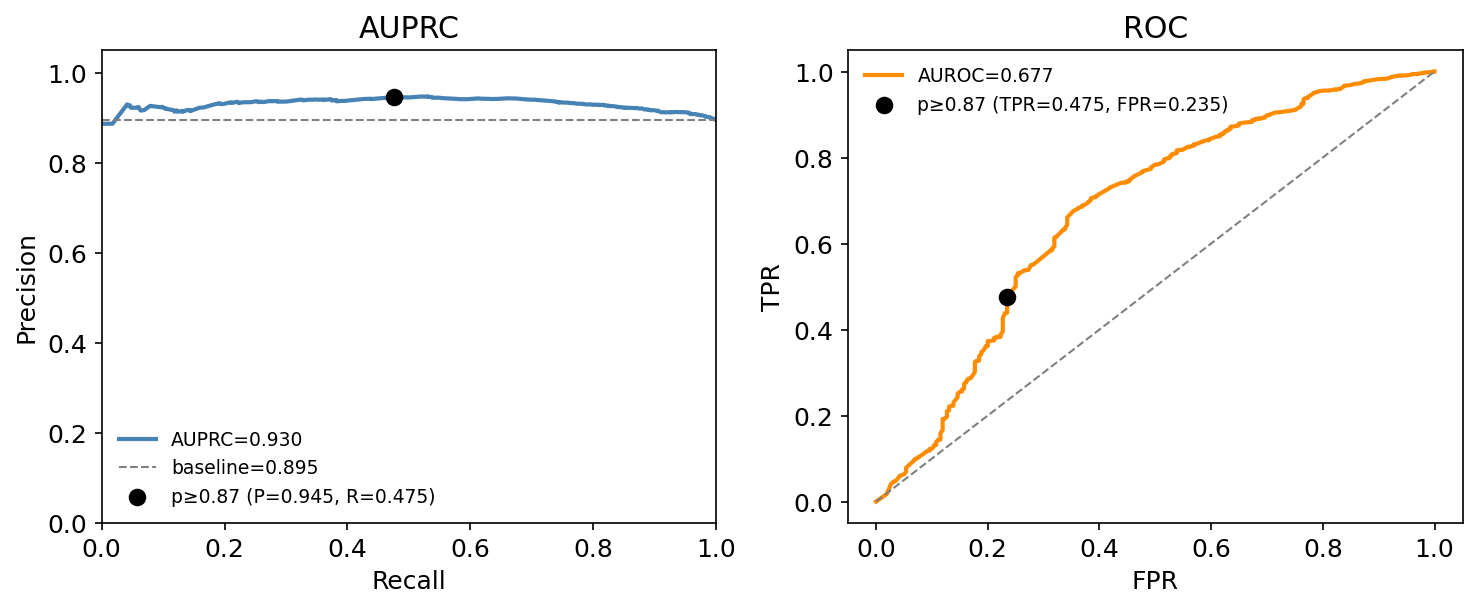

**he6_score_distributions.png**

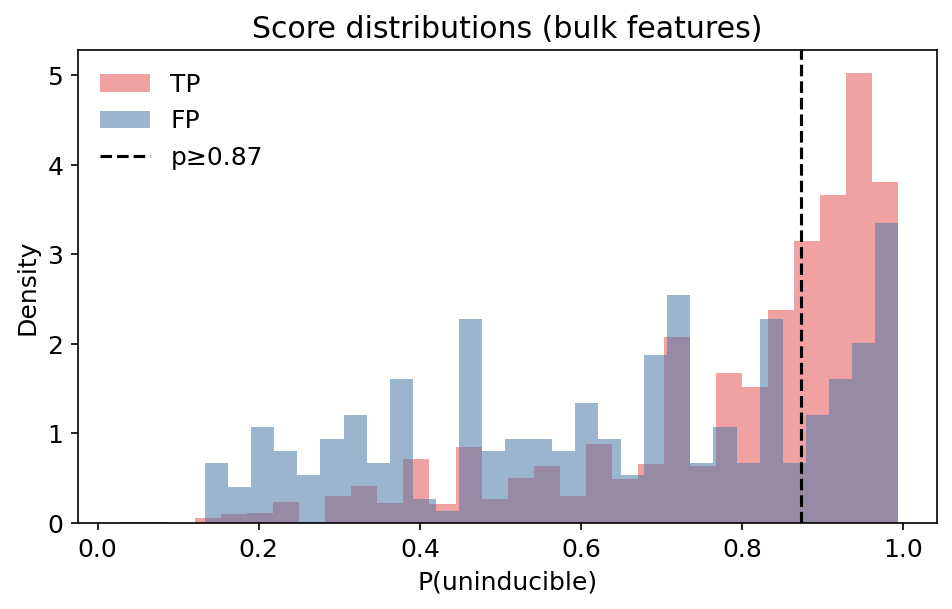

**he6_prop_called.png**

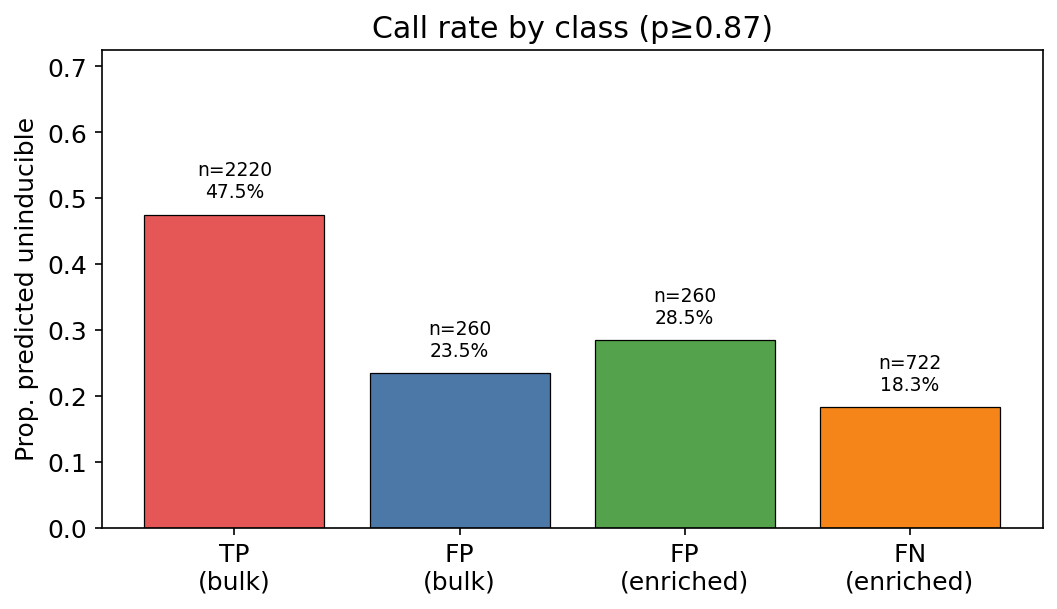

**he6_bulk_vs_enriched_stacked_by_sample.png**

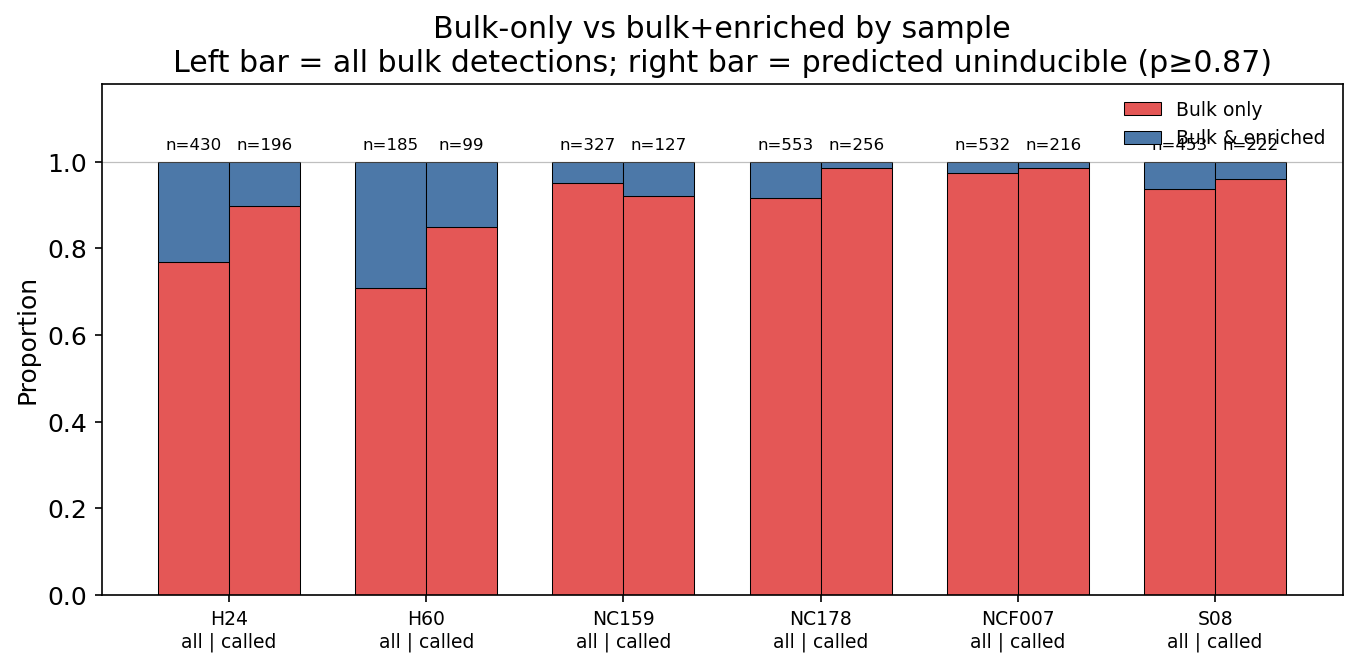

**he6_bulk_vs_enriched_pre_post_filter.png**

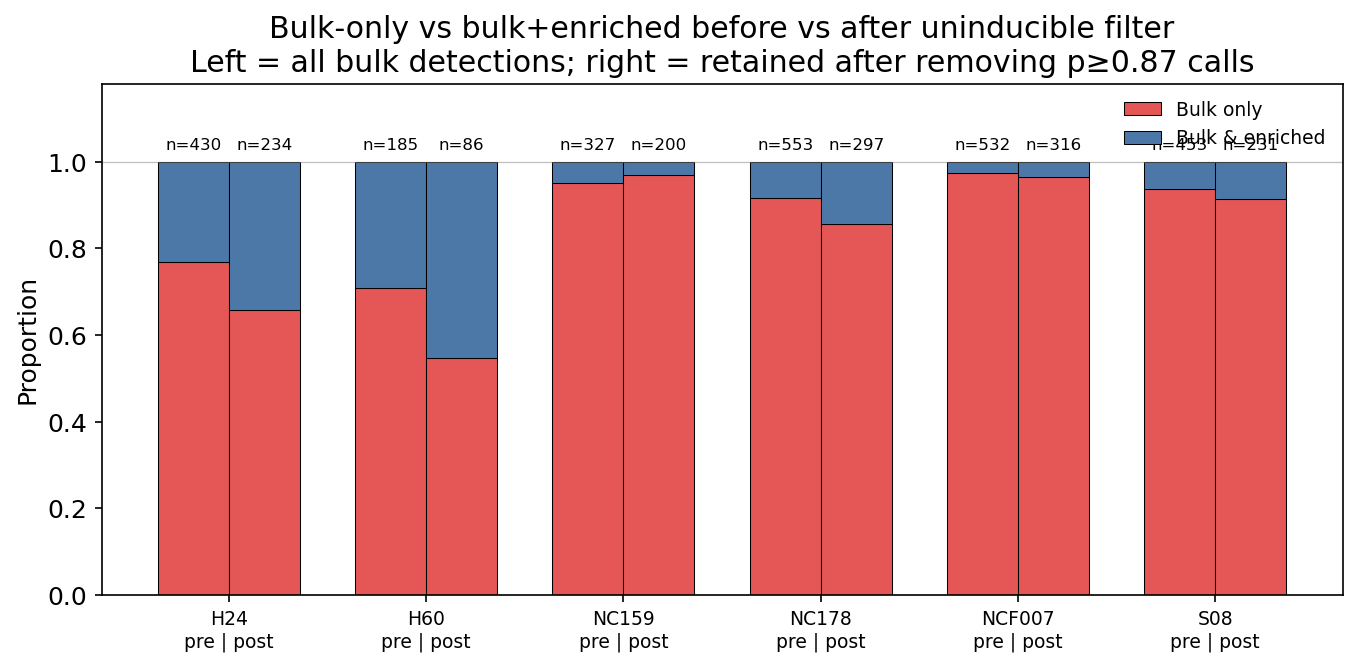

**he6_pre_post_filter_boxplot.png**

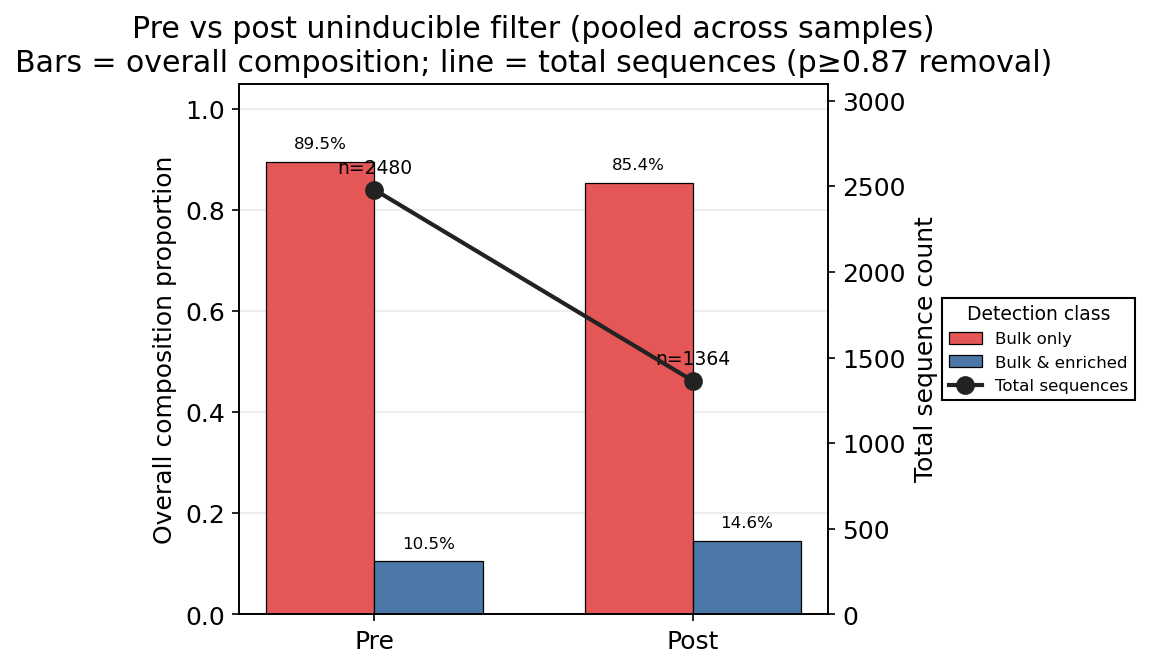

**he6_vhr_cascade_pre_post.png**

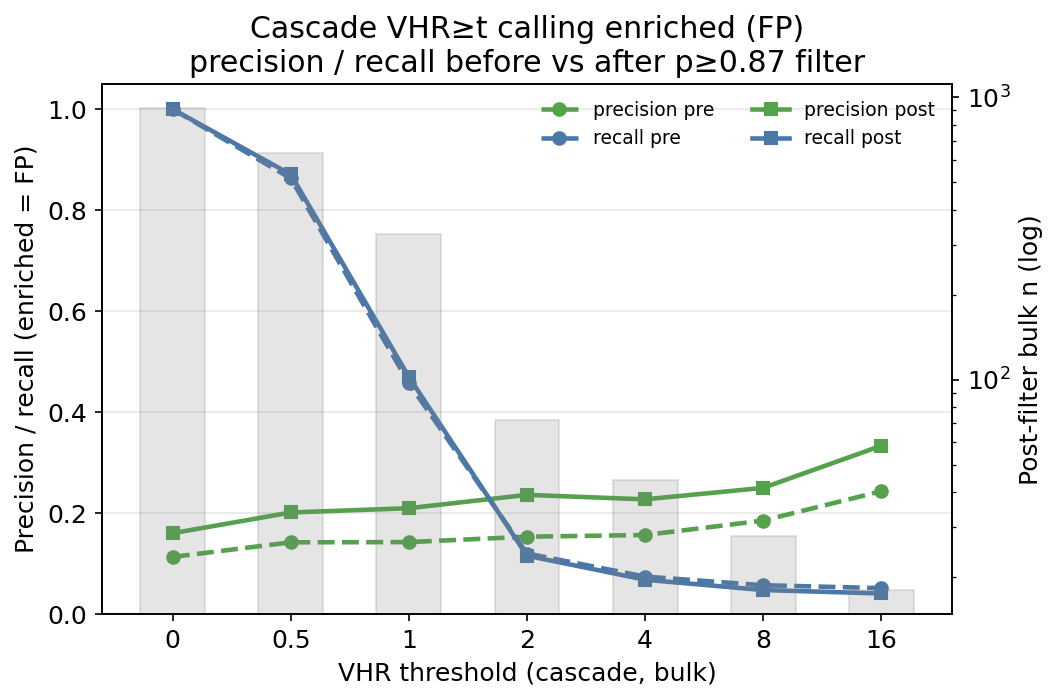

In [42]:
### display key outputs
from IPython.display import display, Image, Markdown
import json

summary = json.loads((OUT_DIR / "he6_summary.json").read_text())
display(Markdown(f"""### Summary
- **Pairs:** {', '.join(summary['pairs'])}
- **Threshold:** p ≥ {summary['threshold']:.2f}
- **AUROC / AUPRC:** {summary['auroc']:.3f} / {summary['auprc']:.3f}
- **Precision / recall @ thresh:** {summary['precision_at_thresh']:.3f} / {summary['recall_at_thresh']:.3f}
- **Mean feature null frac:** {summary['mean_feature_null_frac']:.3f}
"""))
for name in [
    "he6_pr_roc.png",
    "he6_score_distributions.png",
    "he6_prop_called.png",
    "he6_bulk_vs_enriched_stacked_by_sample.png",
    "he6_bulk_vs_enriched_pre_post_filter.png",
    "he6_pre_post_filter_boxplot.png",
    "he6_vhr_cascade_pre_post.png",
]:
    display(Markdown(f"**{name}**"))
    display(Image(filename=str(OUT_DIR / name)))
